In [1]:
pip show torch

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, stable-baselines3, timm, torchaudio, torchdata, torchmetrics, torchvision
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip show torchvision

Name: torchvision
Version: 0.21.0+cu124
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, pillow, torch
Required-by: easyocr, fastai, timm
Note: you may need to restart the kernel to use updated packages.


8-CLASS OCT CLASSIFICATION USING FASTVIT
CUDA available: True
CUDA device: Tesla P100-PCIE-16GB

=== INITIALIZING DATA PROCESSOR ===
=== SCANNING DATASET STRUCTURE ===

TRAIN SET:
Available classes: ['DR', 'AMD', 'CSR', 'DRUSEN', 'CNV', 'NORMAL', 'MH', 'DME']
  DR: 2300 images
  NORMAL: 2300 images
  DME: 2300 images
  AMD: 2300 images
  CNV: 2300 images
  DRUSEN: 2300 images
  MH: 2300 images
  CSR: 2300 images
  Total train images: 18400

TEST SET:
Available classes: ['DR', 'AMD', 'CSR', 'DRUSEN', 'CNV', 'NORMAL', 'MH', 'DME']
  DR: 350 images
  NORMAL: 350 images
  DME: 350 images
  AMD: 350 images
  CNV: 350 images
  DRUSEN: 350 images
  MH: 350 images
  CSR: 350 images
  Total test images: 2800

VAL SET:
Available classes: ['DR', 'AMD', 'CSR', 'DRUSEN', 'CNV', 'NORMAL', 'MH', 'DME']
  DR: 350 images
  NORMAL: 350 images
  DME: 350 images
  AMD: 350 images
  CNV: 350 images
  DRUSEN: 350 images
  MH: 350 images
  CSR: 350 images
  Total val images: 2800

=== CREATING DATAFRAMES FRO

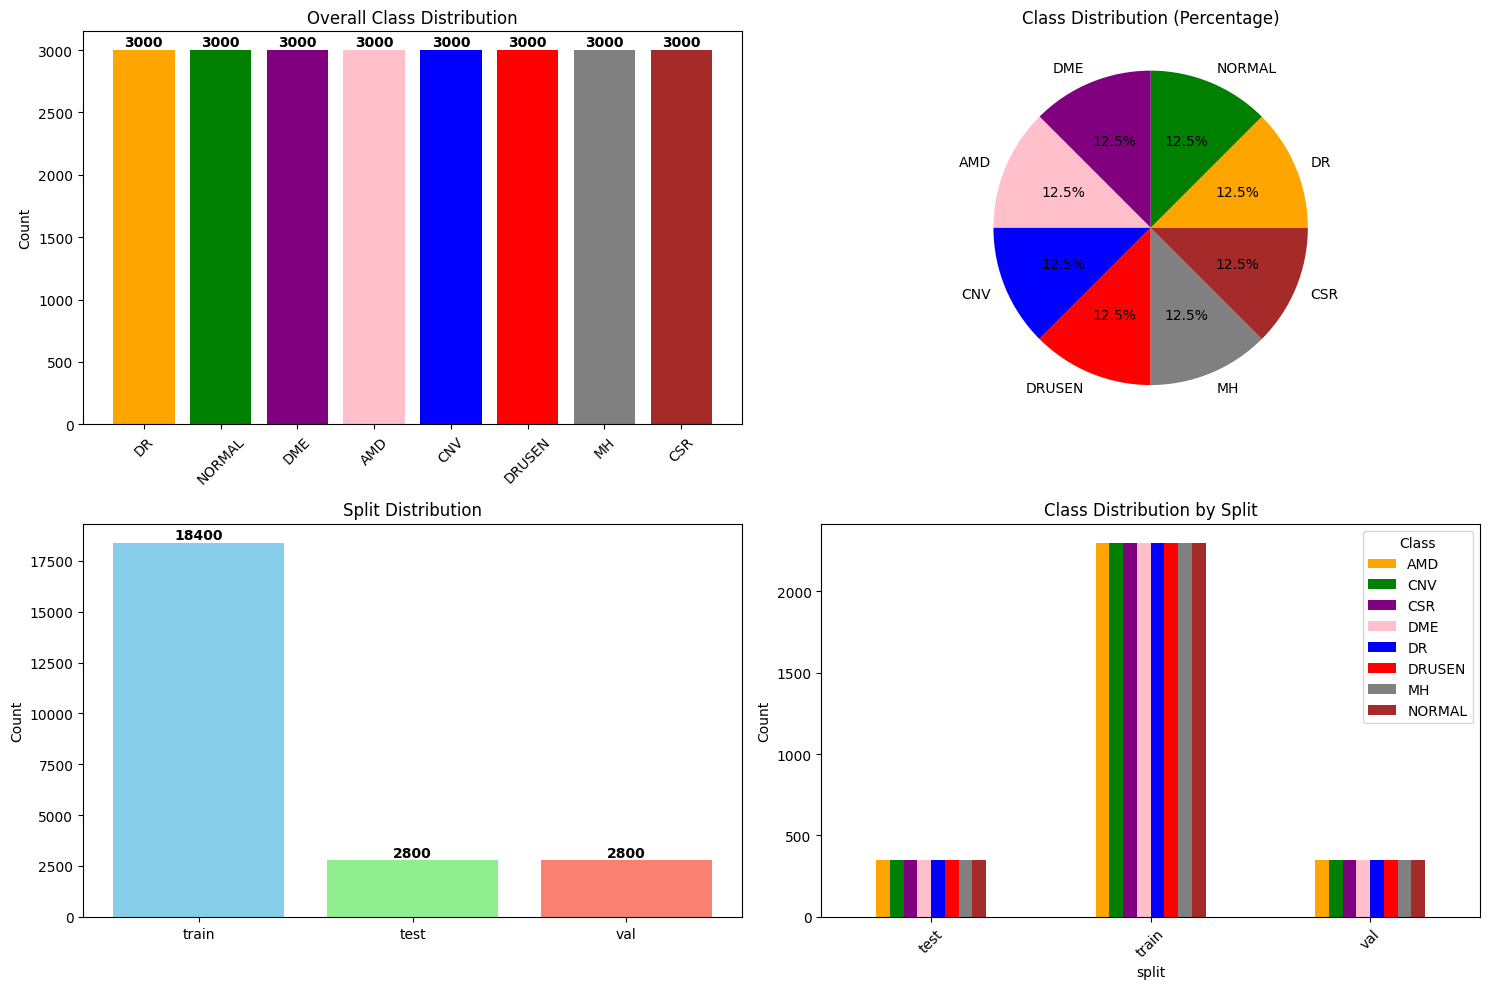


=== TRAINING FASTVIT MODEL ===
Training samples: 18400
Validation samples: 2800

=== BUILDING FASTVIT MODEL: fastvit_t8 ===
Device: cuda
Total parameters: 3,263,384
Trainable parameters: 3,263,384
Model architecture: fastvit_t8
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}
Starting training for 30 epochs...
Epoch [1/30], Batch [0/575], Loss: 2.0558
Epoch [1/30], Batch [50/575], Loss: 0.6599
Epoch [1/30], Batch [100/575], Loss: 0.3983
Epoch [1/30], Batch [150/575], Loss: 0.3871
Epoch [1/30], Batch [200/575], Loss: 0.4719
Epoch [1/30], Batch [250/575], Loss: 0.2191
Epoch [1/30], Batch [300/575], Loss: 0.2206
Epoch [1/30], Batch [350/575], Loss: 0.1294
Epoch [1/30], Batch [400/575], Loss: 0.1162
Epoch [1/30], Batch [450/575], Loss: 0.1940
Epoch [1/30], Batch [500/575], Loss: 0.3512
Epoch [1/30], Batch [550/575], Loss: 0.2838
Epoch [1/30]: Train Loss: 0.3992, Train Acc: 85.74%, Val Loss: 0.3152, Val Acc: 89.32%
New best model saved with validation accurac

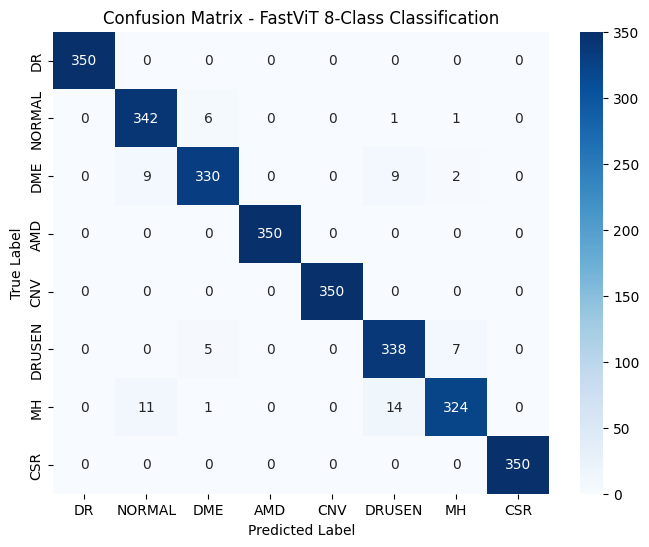

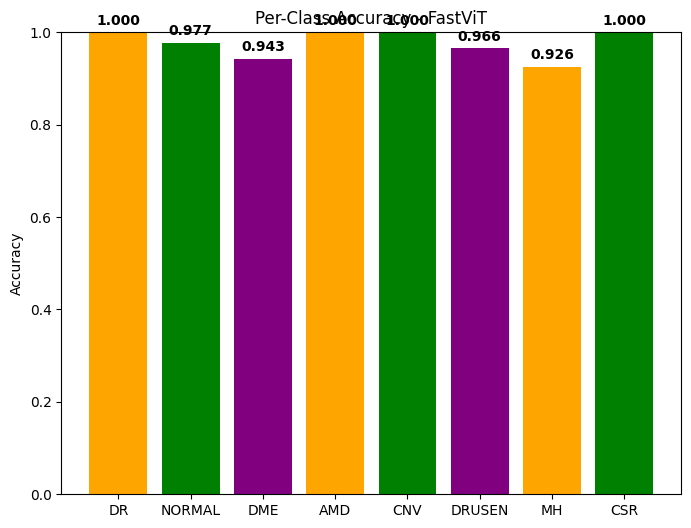

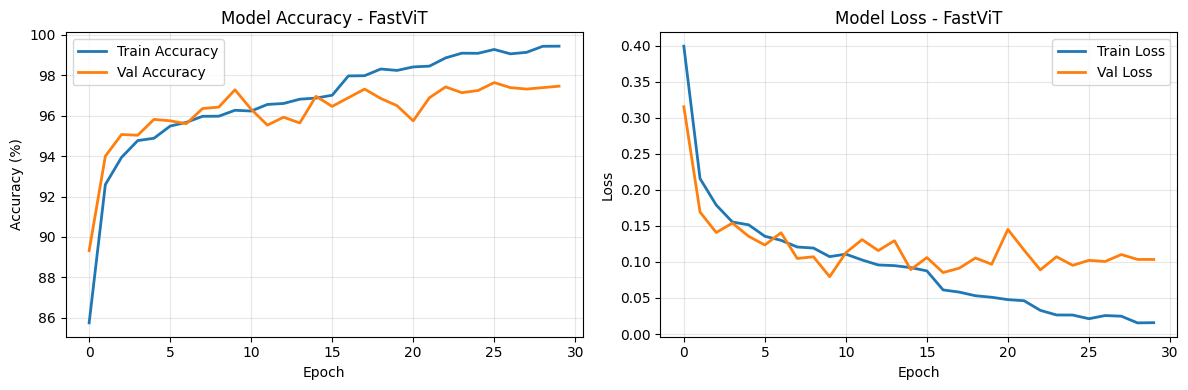


=== EVALUATING ON TEST SET ===
Test samples: 2800
Test Accuracy: 0.9768

Test Set Classification Report:
              precision    recall  f1-score   support

          DR       1.00      1.00      1.00       350
      NORMAL       0.93      0.98      0.95       350
         DME       0.97      0.94      0.95       350
         AMD       1.00      1.00      1.00       350
         CNV       1.00      1.00      1.00       350
      DRUSEN       0.95      0.96      0.96       350
          MH       0.97      0.93      0.95       350
         CSR       1.00      1.00      1.00       350

    accuracy                           0.98      2800
   macro avg       0.98      0.98      0.98      2800
weighted avg       0.98      0.98      0.98      2800



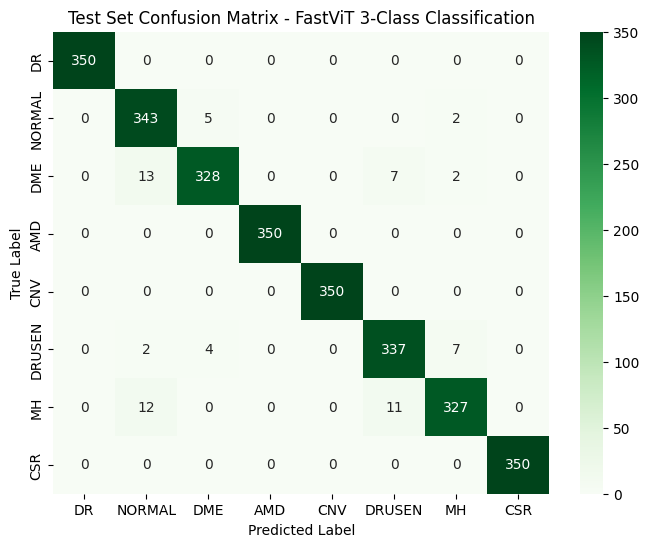


=== REPARAMETERIZING MODEL FOR INFERENCE ===

UNEXPECTED ERROR: name 'reparameterize_model' is not defined


Traceback (most recent call last):
  File "/tmp/ipykernel_35/4116550153.py", line 710, in main
    model_inf = reparameterize_model(model)
                ^^^^^^^^^^^^^^^^^^^^
NameError: name 'reparameterize_model' is not defined


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import cv2
from PIL import Image
import warnings
from pathlib import Path
from collections import Counter
import random

# FastViT imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from timm.models import create_model


warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

class OCTDataProcessor:
    """Data processor for OCT images with directory-based class structure"""
    
    def __init__(self, base_data_dir, target_classes=['DR', 'NORMAL', 'DME' ,'AMD','CNV','DRUSEN','MH','CSR']):
        self.base_data_dir = base_data_dir
        self.target_classes = target_classes
        self.train_dir = os.path.join(base_data_dir, 'train')
        self.test_dir = os.path.join(base_data_dir, 'test')
        self.val_dir = os.path.join(base_data_dir, 'val')
        
        # For 3-class classification
        self.class_mapping = {
            'DR': 0,
            'NORMAL': 1,
            'DME': 2,
            'AMD':3,
            'MH':4,
            'CNV':5,
            'DRUSEN':6,
            'CSR':7
            
        }
        
        # Initialize label encoder
        self.label_encoder = LabelEncoder()
        self.label_encoder.fit(target_classes)
        
    def scan_dataset_structure(self):
        """Scan the dataset structure and create file mappings"""
        print("=== SCANNING DATASET STRUCTURE ===")
        
        datasets = {}
        
        for split in ['train', 'test', 'val']:
            split_dir = os.path.join(self.base_data_dir, split)
            
            if not os.path.exists(split_dir):
                print(f"Warning: {split} directory not found: {split_dir}")
                continue
                
            datasets[split] = {}
            split_total = 0
            
            print(f"\n{split.upper()} SET:")
            
            # Check available classes
            available_classes = [d for d in os.listdir(split_dir) 
                               if os.path.isdir(os.path.join(split_dir, d))]
            
            print(f"Available classes: {available_classes}")
            
            for class_name in self.target_classes:
                class_dir = os.path.join(split_dir, class_name)
                
                if os.path.exists(class_dir):
                    images = [f for f in os.listdir(class_dir) 
                             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    
                    datasets[split][class_name] = {
                        'path': class_dir,
                        'images': images,
                        'count': len(images)
                    }
                    
                    split_total += len(images)
                    print(f"  {class_name}: {len(images)} images")
                else:
                    print(f"  {class_name}: NOT FOUND")
                    datasets[split][class_name] = {
                        'path': class_dir,
                        'images': [],
                        'count': 0
                    }
            
            print(f"  Total {split} images: {split_total}")
        
        self.datasets = datasets
        return datasets
    
    def create_dataframe_from_directories(self):
        """Create pandas DataFrames from directory structure"""
        print("\n=== CREATING DATAFRAMES FROM DIRECTORIES ===")
        
        dataframes = {}
        
        for split in ['train', 'test', 'val']:
            if split not in self.datasets:
                continue
                
            data_list = []
            
            for class_name in self.target_classes:
                if class_name in self.datasets[split]:
                    class_data = self.datasets[split][class_name]
                    class_path = class_data['path']
                    
                    for img_name in class_data['images']:
                        img_path = os.path.join(class_path, img_name)
                        class_label = self.class_mapping[class_name]
                        
                        data_list.append({
                            'image_path': img_path,
                            'image_name': img_name,
                            'class': class_name,
                            'class_label': class_label,
                            'split': split
                        })
            
            df = pd.DataFrame(data_list)
            dataframes[split] = df
            
            print(f"{split.upper()} DataFrame shape: {df.shape}")
            if len(df) > 0:
                print(f"  Class distribution: {dict(df['class'].value_counts())}")
                print(f"  Numeric label distribution: {dict(df['class_label'].value_counts())}")
        
        return dataframes
    
    def analyze_dataset_distribution(self, dataframes):
        """Analyze and visualize dataset distribution"""
        print("\n=== DATASET DISTRIBUTION ANALYSIS ===")
        
        # Combine all splits for overall analysis
        all_data = []
        for split, df in dataframes.items():
            if len(df) > 0:
                all_data.append(df)
        
        if not all_data:
            print("No data found!")
            return
        
        combined_df = pd.concat(all_data, ignore_index=True)
        
        print("Overall Distribution:")
        print(f"Total images: {len(combined_df)}")
        print(f"Class distribution: {dict(combined_df['class'].value_counts())}")
        
        # Create visualizations
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Overall class distribution
        class_dist = combined_df['class'].value_counts()
        colors = ['orange', 'green', 'purple','pink','blue','red','grey','brown']
        bars = axes[0,0].bar(class_dist.index, class_dist.values, color=colors)
        axes[0,0].set_title('Overall Class Distribution')
        axes[0,0].set_ylabel('Count')
        axes[0,0].tick_params(axis='x', rotation=45)
        for i, v in enumerate(class_dist.values):
            axes[0,0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
        
        # Class distribution pie chart
        axes[0,1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', colors=colors)
        axes[0,1].set_title('Class Distribution (Percentage)')
        
        # Split distribution
        split_dist = combined_df['split'].value_counts()
        axes[1,0].bar(split_dist.index, split_dist.values, color=['skyblue', 'lightgreen', 'salmon'])
        axes[1,0].set_title('Split Distribution')
        axes[1,0].set_ylabel('Count')
        for i, v in enumerate(split_dist.values):
            axes[1,0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
        
        # Class distribution by split
        split_class = combined_df.groupby(['split', 'class']).size().unstack(fill_value=0)
        split_class.plot(kind='bar', ax=axes[1,1], color=colors)
        axes[1,1].set_title('Class Distribution by Split')
        axes[1,1].set_ylabel('Count')
        axes[1,1].legend(title='Class')
        axes[1,1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig('dataset_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return combined_df

class OCTDataset(Dataset):
    """PyTorch Dataset for OCT images"""
    
    def __init__(self, df, transform=None, target_size=(224, 224)):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_size = target_size
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        try:
            # Get image path and label
            img_path = self.df.iloc[idx]['image_path']
            label = self.df.iloc[idx]['class_label']
            
            # Load image
            image = Image.open(img_path).convert('RGB')
            image = image.resize(self.target_size)
            
            # Apply transforms
            if self.transform:
                image = self.transform(image)
            
            return image, label
            
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image as fallback
            blank_image = Image.new('RGB', self.target_size, (0, 0, 0))
            if self.transform:
                blank_image = self.transform(blank_image)
            return blank_image, 0

class FastViTModel:
    """FastViT model wrapper for 8-class classification"""
    
    def __init__(self, model_name="fastvit_t8", num_classes=8, pretrained=True):
        self.model_name = model_name
        self.num_classes = num_classes
        self.pretrained = pretrained
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    def build_model(self):
        """Build FastViT model for 8-class classification"""
        print(f"\n=== BUILDING FASTVIT MODEL: {self.model_name} ===")
        print(f"Device: {self.device}")
        
        # Create FastViT model
        model = create_model(
            self.model_name,
            pretrained=self.pretrained,
            num_classes=self.num_classes
        )
        
        # Move to device
        model = model.to(self.device)
        
        # Print model info
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
        print(f"Model architecture: {self.model_name}")
        
        return model

class ModelTrainer:
    """Train and evaluate FastViT model"""
    
    def __init__(self, data_processor, model_builder):
        self.data_processor = data_processor
        self.model_builder = model_builder
        self.model = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.results = {}
        
    def get_transforms(self):
        """Get data transforms for training and validation"""
        
        # Training transforms with augmentation
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomRotation(15),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.1),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # Validation/test transforms without augmentation
        val_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        return train_transform, val_transform
    
    def train_model(self, dataframes, epochs=30, batch_size=32, learning_rate=0.001):
        """Train the FastViT model"""
        print("\n=== TRAINING FASTVIT MODEL ===")
        
        # Get training and validation data
        train_df = dataframes.get('train', pd.DataFrame())
        val_df = dataframes.get('val', pd.DataFrame())
        
        # If no validation set, create one from training data
        if len(val_df) == 0 and len(train_df) > 0:
            print("No validation set found. Creating validation split from training data...")
            train_df, val_df = train_test_split(
                train_df, 
                test_size=0.2, 
                stratify=train_df['class_label'], 
                random_state=42
            )
        
        print(f"Training samples: {len(train_df)}")
        print(f"Validation samples: {len(val_df)}")
        
        # Get transforms
        train_transform, val_transform = self.get_transforms()
        
        # Create datasets
        train_dataset = OCTDataset(train_df, transform=train_transform)
        val_dataset = OCTDataset(val_df, transform=val_transform)
        
        # Create data loaders
        train_loader = DataLoader(
            train_dataset, 
            batch_size=batch_size, 
            shuffle=True, 
            num_workers=4,
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        val_loader = DataLoader(
            val_dataset, 
            batch_size=batch_size, 
            shuffle=False, 
            num_workers=4,
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        # Build model
        self.model = self.model_builder.build_model()
        
        # Calculate class weights for handling any imbalance
        if len(train_df) > 0:
            classes = np.unique(train_df['class_label'])
            class_weights = compute_class_weight('balanced', classes=classes, y=train_df['class_label'])
            class_weight_tensor = torch.FloatTensor(class_weights).to(self.device)
            print(f"Class weights: {dict(zip(classes, class_weights))}")
        else:
            class_weight_tensor = None
        
        # Loss function and optimizer
        criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
        optimizer = optim.AdamW(self.model.parameters(), lr=learning_rate, weight_decay=0.01)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        
        # Training loop
        train_losses = []
        train_accuracies = []
        val_losses = []
        val_accuracies = []
        best_val_acc = 0.0
        patience_counter = 0
        patience = 10
        
        print(f"Starting training for {epochs} epochs...")
        
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0
            
            for batch_idx, (images, labels) in enumerate(train_loader):
                images, labels = images.to(self.device), labels.to(self.device)
                
                optimizer.zero_grad()
                outputs = self.model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()
                
                if batch_idx % 50 == 0:
                    print(f'Epoch [{epoch+1}/{epochs}], Batch [{batch_idx}/{len(train_loader)}], '
                          f'Loss: {loss.item():.4f}')
            
            train_acc = 100 * train_correct / train_total
            train_loss = train_loss / len(train_loader)
            
            # Validation phase
            self.model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = self.model(images)
                    loss = criterion(outputs, labels)
                    
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
            
            val_acc = 100 * val_correct / val_total
            val_loss = val_loss / len(val_loader)
            
            # Store metrics
            train_losses.append(train_loss)
            train_accuracies.append(train_acc)
            val_losses.append(val_loss)
            val_accuracies.append(val_acc)
            
            # Print epoch results
            print(f'Epoch [{epoch+1}/{epochs}]: '
                  f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
            
            # Learning rate scheduling
            scheduler.step(val_loss)
            
            # Early stopping and model saving
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                # Save best model
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_loss': val_loss
                }, 'fastvit_oct_best.pth')
                print(f'New best model saved with validation accuracy: {val_acc:.2f}%')
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f'Early stopping triggered after {epoch+1} epochs')
                    break
        
        # Store training history
        self.history = {
            'train_loss': train_losses,
            'train_accuracy': train_accuracies,
            'val_loss': val_losses,
            'val_accuracy': val_accuracies
        }
        
        # Load best model
        checkpoint = torch.load('fastvit_oct_best.pth')
        self.model.load_state_dict(checkpoint['model_state_dict'])
        
        # Evaluate model
        self.evaluate_model(val_loader, val_df)
        
        return self.model, self.history
    
    def evaluate_model(self, val_loader, val_df):
        """Evaluate model performance"""
        print("\n=== EVALUATING MODEL PERFORMANCE ===")
        
        self.model.eval()
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs, 1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate accuracy
        accuracy = np.mean(np.array(all_labels) == np.array(all_predictions))
        print(f"Validation Accuracy: {accuracy:.4f}")
        
        # Classification report
        class_names = self.data_processor.target_classes
        print("\nClassification Report:")
        print(classification_report(all_labels, all_predictions, target_names=class_names))
        
        # Confusion matrix
        cm = confusion_matrix(all_labels, all_predictions)
        print(f"\nConfusion Matrix:")
        print(cm)
        
        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, 
                   yticklabels=class_names)
        plt.title('Confusion Matrix - FastViT 8-Class Classification')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.savefig('confusion_matrix_fastvit.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Plot per-class accuracy
        class_accuracy = cm.diagonal() / cm.sum(axis=1)
        plt.figure(figsize=(8, 6))
        bars = plt.bar(class_names, class_accuracy, color=['orange', 'green', 'purple'])
        plt.title('Per-Class Accuracy - FastViT')
        plt.ylabel('Accuracy')
        plt.ylim(0, 1)
        
        # Add value labels on bars
        for bar, acc in zip(bars, class_accuracy):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
        
        plt.savefig('per_class_accuracy_fastvit.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        self.results = {
            'accuracy': accuracy,
            'y_true': all_labels,
            'y_pred': all_predictions,
            'class_names': class_names
        }
        
        return self.results
    
    def evaluate_test_set(self, dataframes):
        """Evaluate on test set if available"""
        test_df = dataframes.get('test', pd.DataFrame())
        
        if len(test_df) == 0:
            print("No test set available for evaluation")
            return
        
        print("\n=== EVALUATING ON TEST SET ===")
        print(f"Test samples: {len(test_df)}")
        
        # Get transforms
        _, test_transform = self.get_transforms()
        
        # Create test dataset and loader
        test_dataset = OCTDataset(test_df, transform=test_transform)
        test_loader = DataLoader(
            test_dataset, 
            batch_size=32, 
            shuffle=False, 
            num_workers=4,
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        # Get predictions
        self.model.eval()
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs, 1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate metrics
        accuracy = np.mean(np.array(all_labels) == np.array(all_predictions))
        print(f"Test Accuracy: {accuracy:.4f}")
        
        # Classification report
        class_names = self.data_processor.target_classes
        print("\nTest Set Classification Report:")
        print(classification_report(all_labels, all_predictions, target_names=class_names))
        
        # Confusion matrix
        cm = confusion_matrix(all_labels, all_predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                   xticklabels=class_names, 
                   yticklabels=class_names)
        plt.title('Test Set Confusion Matrix - FastViT 3-Class Classification')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.savefig('test_confusion_matrix_fastvit.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return {
            'test_accuracy': accuracy,
            'test_y_true': all_labels,
            'test_y_pred': all_predictions
        }
    
    def plot_training_history(self):
        """Plot training history"""
        if not hasattr(self, 'history') or self.history is None:
            print("No training history available")
            return
        
        plt.figure(figsize=(12, 4))
        
        # Plot accuracy
        plt.subplot(1, 2, 1)
        plt.plot(self.history['train_accuracy'], label='Train Accuracy', linewidth=2)
        plt.plot(self.history['val_accuracy'], label='Val Accuracy', linewidth=2)
        plt.title('Model Accuracy - FastViT')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot loss
        plt.subplot(1, 2, 2)
        plt.plot(self.history['train_loss'], label='Train Loss', linewidth=2)
        plt.plot(self.history['val_loss'], label='Val Loss', linewidth=2)
        plt.title('Model Loss - FastViT')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_history_fastvit.png', dpi=300, bbox_inches='tight')
        plt.show()

def main():
    """Main execution function"""
    print("="*60)
    print("8-CLASS OCT CLASSIFICATION USING FASTVIT")
  
    print("="*60)
    
    # Configuration - UPDATE THIS PATH
    BASE_DATA_DIR = "/kaggle/input/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset"  # Update with your dataset path
    TARGET_CLASSES =['DR', 'NORMAL', 'DME' ,'AMD','CNV','DRUSEN','MH','CSR']
    MODEL_NAME = "fastvit_t8"  # Options: fastvit_t8, fastvit_t12, fastvit_s12, fastvit_sa12, fastvit_sa24, fastvit_sa36, fastvit_ma36
    
    try:
        # Check if CUDA is available
        print(f"CUDA available: {torch.cuda.is_available()}")
        if torch.cuda.is_available():
            print(f"CUDA device: {torch.cuda.get_device_name()}")
        
        # Initialize data processor
        print("\n=== INITIALIZING DATA PROCESSOR ===")
        data_processor = OCTDataProcessor(BASE_DATA_DIR, TARGET_CLASSES)
        
        # Scan dataset structure
        datasets = data_processor.scan_dataset_structure()
        
        # Create dataframes
        dataframes = data_processor.create_dataframe_from_directories()
        
        # Analyze distribution
        combined_df = data_processor.analyze_dataset_distribution(dataframes)
        
        # Initialize model builder
        model_builder = FastViTModel(model_name=MODEL_NAME, num_classes=8) 
        # Initialize trainer
        trainer = ModelTrainer(data_processor, model_builder)
        
        # Train model
        model, history = trainer.train_model(
            dataframes, 
            epochs=30, 
            batch_size=32, 
            learning_rate=0.001
        )
        
        # Plot training history
        trainer.plot_training_history()
        
        # Evaluate on test set if available
        test_results = trainer.evaluate_test_set(dataframes)
        
        # Reparameterize model for inference (optional)
        print("\n=== REPARAMETERIZING MODEL FOR INFERENCE ===")
        model.eval()
        model_inf = reparameterize_model(model)
        
        # Save reparameterized model
        torch.save({
            'model_state_dict': model_inf.state_dict(),
            'model_name': MODEL_NAME,
            'num_classes': 8,
            'class_names': TARGET_CLASSES
        }, 'fastvit_oct_inference.pth')
        
        print("\n" + "="*60)
        print("TRAINING COMPLETED SUCCESSFULLY!")
        print("="*60)
        print(f"Model: {MODEL_NAME}")
        print(f"Training model saved as: fastvit_oct_best.pth")
        print(f"Inference model saved as: fastvit_oct_inference.pth")
        print(f"Training plots saved")
        
        return trainer
        
    except FileNotFoundError as e:
        print(f"\nERROR: {e}")
        print("\nPlease ensure:")
        print("1. Dataset directory exists and contains train/test/val folders")
        print("3. FastViT model files are available (install timm and fastvit)")
        print(f"\nCurrent configuration:")
        print(f"- Base directory: {BASE_DATA_DIR}")
        print(f"- Target classes: {TARGET_CLASSES}")
        print(f"- Model: {MODEL_NAME}")
        
        return None
    
    except Exception as e:
        print(f"\nUNEXPECTED ERROR: {e}")
        import traceback
        traceback.print_exc()
        return None

# Usage example
if __name__ == "__main__":
    # Run the main pipeline
    trainer = main()
    
    # Example of how to load and use the inference model
    if trainer is not None:
        print("\n=== EXAMPLE: LOADING INFERENCE MODEL ===")
        
        # Load the inference model
        checkpoint = torch.load('fastvit_oct_inference.pth')
        
        # Create model for inference
        inference_model = create_model(
            checkpoint['model_name'],
            pretrained=False,
            num_classes=checkpoint['num_classes']
        )